# 🔬 Breast Cancer Diagnosis — End-to-End ML Pipeline
**Dataset:** Enhanced Breast Cancer Diagnostic Dataset (5,500 samples, 15 features)  
**Goal:** Binary classification — Malignant (1) vs Benign (0)  
**Framework:** TensorFlow / Keras

---
### Pipeline stages
1. Environment setup & data loading  
2. Exploratory data analysis (EDA)  
3. Preprocessing & splitting  
4. Model building (neural network)  
5. Evaluation & tuning  
6. Save & interpret


---
## Stage 1 · Environment Setup & Data Loading
Install once from your terminal if needed:
```bash
pip install tensorflow pandas numpy matplotlib seaborn scikit-learn
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


TensorFlow: 2.20.0
NumPy: 2.2.6
Pandas: 2.3.3


In [2]:
# Update this path if your CSV is elsewhere
DATA_PATH = "dataset/breast_cancer_enhanced_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()


Shape: (5500, 17)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,shape_irregularity,border_complexity,tumor_aggressiveness,radius_texture_interaction,radius_concavity_interaction,concavity_density,malignancy_risk_score
0,5.683796e+06,B,11.829858,21.726166,75.154378,435.022394,0.087089,0.050717,0.015868,0.011641,0.078226,0.000185,0.026075,257.017451,0.187718,0.000036,22.433798
1,-6.253379e+06,B,10.991150,17.103260,71.798929,381.386295,0.089339,0.109498,0.097344,0.035629,0.242470,0.003468,0.080823,187.984489,1.069921,0.000255,24.021839
2,4.213892e+06,M,21.433519,15.092437,142.753006,1392.399890,0.099557,0.152079,0.193372,0.126922,0.472373,0.024543,0.157458,323.484034,4.144647,0.000139,49.053992
3,-2.986069e+06,B,11.700452,14.872127,74.154481,404.112556,0.101291,0.077563,0.043749,0.028747,0.150059,0.001258,0.050020,174.010599,0.511885,0.000108,23.276145
4,6.469594e+05,B,13.259377,17.212990,83.621014,521.124238,0.072905,0.043312,0.046983,0.010096,0.100391,0.000474,0.033464,228.233523,0.622960,0.000090,25.647074


In [3]:
print("=== Missing values ===")
print(df.isnull().sum())

print("\n=== Class balance ===")
counts = df["diagnosis"].value_counts()
print(counts)
print(f"\nMalignant: {counts['M']} ({counts['M']/len(df)*100:.1f}%)")
print(f"Benign:    {counts['B']} ({counts['B']/len(df)*100:.1f}%)")


=== Missing values ===
id                              0
diagnosis                       0
radius_mean                     0
texture_mean                    0
perimeter_mean                  0
area_mean                       0
smoothness_mean                 0
compactness_mean                0
concavity_mean                  0
concave points_mean             0
shape_irregularity              0
border_complexity               0
tumor_aggressiveness            0
radius_texture_interaction      0
radius_concavity_interaction    0
concavity_density               0
malignancy_risk_score           0
dtype: int64

=== Class balance ===
diagnosis
B    3470
M    2030
Name: count, dtype: int64

Malignant: 2030 (36.9%)
Benign:    3470 (63.1%)


---
## Stage 2 · Exploratory Data Analysis (EDA)
We look at class balance, feature distributions, and correlations to understand the data before modelling.


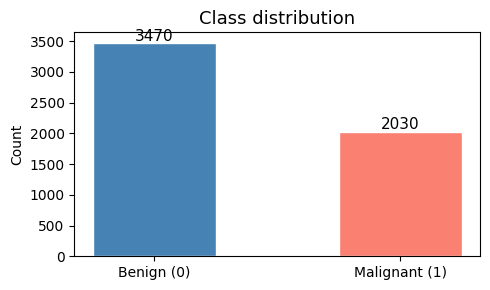

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
colors = ["steelblue", "salmon"]
bars = ax.bar(["Benign (0)", "Malignant (1)"],
              [counts["B"], counts["M"]],
              color=colors, edgecolor="white", width=0.5)
ax.set_title("Class distribution", fontsize=13)
ax.set_ylabel("Count")
for bar, v in zip(bars, [counts["B"], counts["M"]]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 40, str(v),
            ha="center", fontsize=11)
plt.tight_layout()
plt.show()


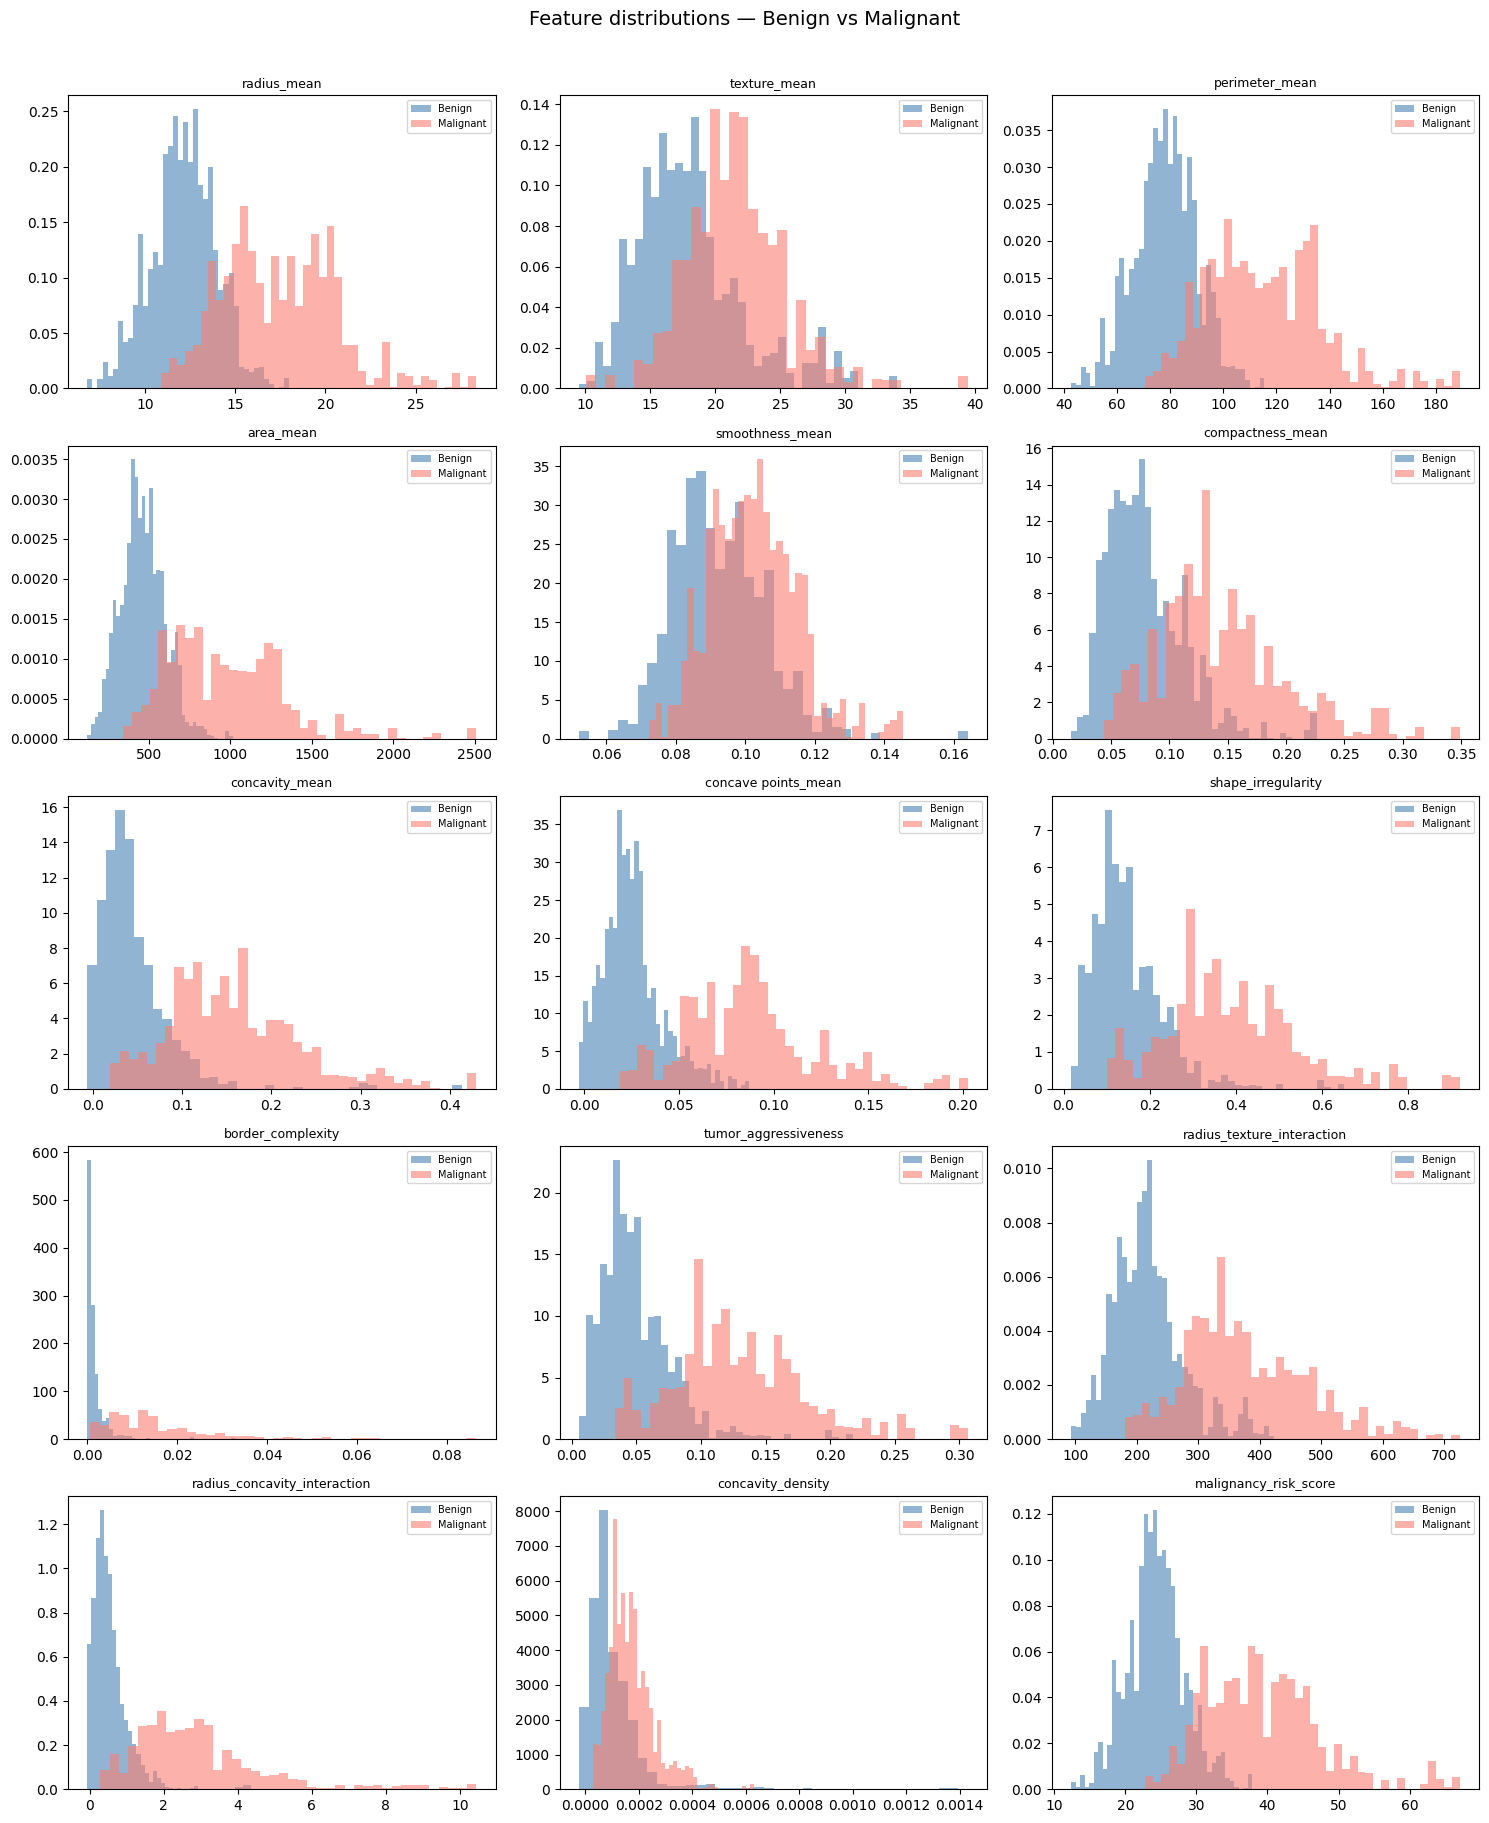

In [5]:
FEATURE_COLS = [
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave points_mean", "shape_irregularity", "border_complexity",
    "tumor_aggressiveness", "radius_texture_interaction",
    "radius_concavity_interaction", "concavity_density",
    "malignancy_risk_score"
]

# Distributions split by diagnosis
fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    for label, color in [("B", "steelblue"), ("M", "salmon")]:
        axes[i].hist(df[df["diagnosis"] == label][col],
                     bins=40, alpha=0.6, color=color,
                     label="Benign" if label == "B" else "Malignant",
                     density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle("Feature distributions — Benign vs Malignant", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


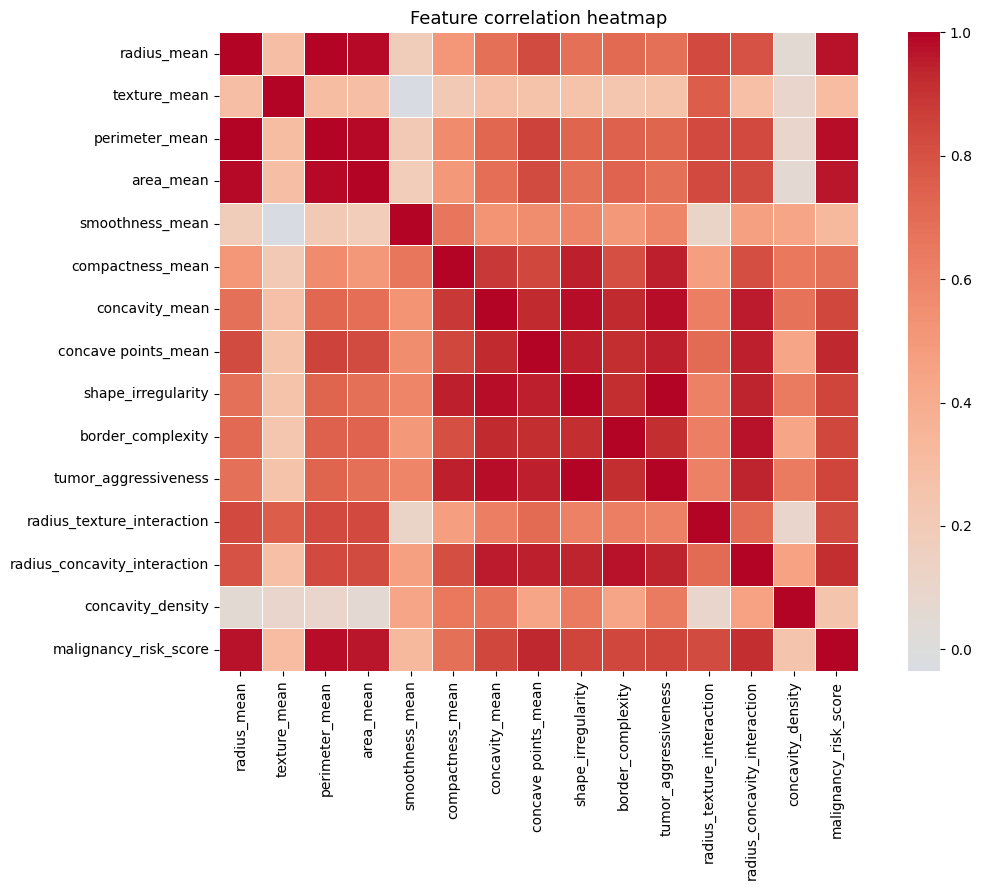

Highly correlated pairs (|r| > 0.9):
radius_mean                   perimeter_mean                  0.996851
                              area_mean                       0.987225
                              malignancy_risk_score           0.968507
perimeter_mean                area_mean                       0.985926
                              malignancy_risk_score           0.981705
area_mean                     malignancy_risk_score           0.962267
compactness_mean              shape_irregularity              0.945034
                              tumor_aggressiveness            0.945034
concavity_mean                concave points_mean             0.925711
                              shape_irregularity              0.983816
                              border_complexity               0.925254
                              tumor_aggressiveness            0.983816
                              radius_concavity_interaction    0.955632
concave points_mean           shape_irre

In [6]:
plt.figure(figsize=(12, 9))
corr = df[FEATURE_COLS].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0,
            linewidths=0.4, square=True)
plt.title("Feature correlation heatmap", fontsize=13)
plt.tight_layout()
plt.show()

# Highly correlated pairs (|r| > 0.9) — candidates for dropping
high_corr = (corr.abs() > 0.9) & (corr.abs() < 1.0)
print("Highly correlated pairs (|r| > 0.9):")
print(corr[high_corr].stack().drop_duplicates())


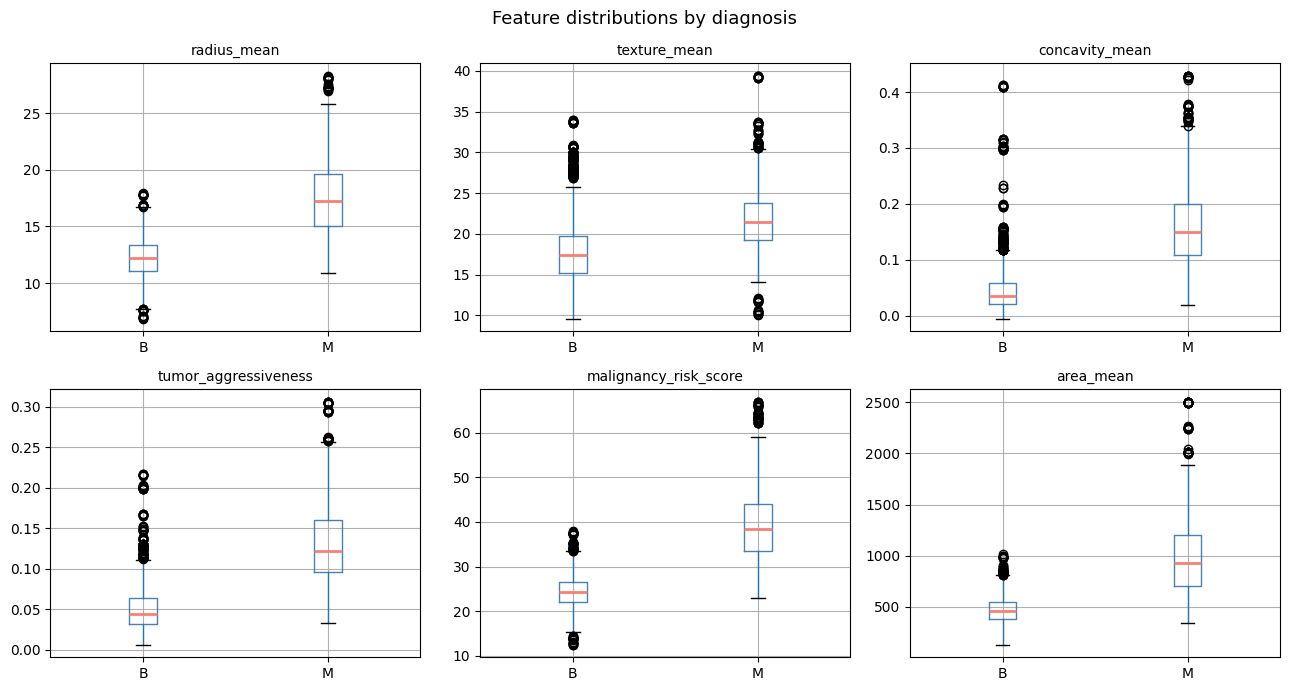

In [7]:
# Boxplots — quickly shows which features separate classes best
plot_features = ["radius_mean", "texture_mean", "concavity_mean",
                 "tumor_aggressiveness", "malignancy_risk_score", "area_mean"]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for i, col in enumerate(plot_features):
    df.boxplot(column=col, by="diagnosis", ax=axes[i],
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="salmon", linewidth=2))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
plt.suptitle("Feature distributions by diagnosis", fontsize=13)
plt.tight_layout()
plt.show()


---
## Stage 3 · Preprocessing & Splitting
- Encode the target label (M → 1, B → 0)  
- Split into train / validation / test (70 / 15 / 15)  
- Normalise features with `StandardScaler` (fit on train only)  
- Compute class weights to handle mild imbalance


In [8]:
X = df[FEATURE_COLS].values
y = (df["diagnosis"] == "M").astype(int).values   # 1=Malignant, 0=Benign

# 70 / 15 / 15 split — stratified to preserve class ratio in each set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765,   # ~15% of total
    random_state=SEED, stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]}  samples")
print(f"Test:       {X_test.shape[0]}  samples")


Train:      3849 samples
Validation: 826  samples
Test:       825  samples


In [9]:
# Fit scaler ONLY on training data — then apply to val & test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train mean after scaling: {X_train_sc.mean():.4f}  (should be ~0)")
print(f"Train std  after scaling: {X_train_sc.std():.4f}   (should be ~1)")


Train mean after scaling: 0.0000  (should be ~0)
Train std  after scaling: 1.0000   (should be ~1)


In [10]:
# Class weights penalise missed malignant predictions more heavily
cw_arr = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: cw_arr[0], 1: cw_arr[1]}
print("Class weights:", {k: round(v, 3) for k, v in class_weight_dict.items()})
# Benign weight ~0.79, Malignant ~1.35


Class weights: {0: np.float64(0.793), 1: np.float64(1.354)}


---
## Stage 4 · Model Building (TensorFlow / Keras)
A feedforward neural network with:
- Two hidden layers (ReLU activation)
- Dropout for regularisation (reduces overfitting)
- Sigmoid output for binary classification
- EarlyStopping to stop when validation loss stops improving


In [11]:
def build_model(input_dim, dropout_rate=0.3, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(32, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(1, activation="sigmoid")   # Output: probability of Malignant
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

model = build_model(input_dim=X_train_sc.shape[1])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model.keras", monitor="val_loss",
        save_best_only=True, verbose=0
    )
]

history = model.fit(
    X_train_sc, y_train,
    validation_data=(X_val_sc, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/150
121/121 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8833 - auc: 0.9529 - loss: 0.3070 - recall: 0.8571 - val_accuracy: 0.9298 - val_auc: 0.9795 - val_loss: 0.1661 - val_recall: 0.8689
Epoch 2/150
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9397 - auc: 0.9840 - loss: 0.1594 - recall: 0.9289 - val_accuracy: 0.9419 - val_auc: 0.9843 - val_loss: 0.1429 - val_recall: 0.8885
Epoch 3/150
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9480 - auc: 0.9888 - loss: 0.1345 - recall: 0.9353 - val_accuracy: 0.9443 - val_auc: 0.9870 - val_loss: 0.1287 - val_recall: 0.8918
Epoch 4/150
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9538 - auc: 0.9901 - loss: 0.1248 - recall: 0.9430 - val_accuracy: 0.9492 - val_auc: 0.9896 - val_loss: 0.1156 - val_recall: 0.9016
Epoch 5/150
121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9545 - auc: 0.9897 - loss: 0.1227 - recall: 0.9409 - val_accuracy: 0.9564 - val_auc: 0.9907 - val_loss: 0.1082 - val_recall: 0.9213
Epoch

---
## Stage 5 · Evaluation & Tuning
Key metrics for medical classification:
- **Recall** (sensitivity) — minimise false negatives (missed cancer)
- **Precision** — minimise false positives (unnecessary alarms)
- **ROC-AUC** — overall model discrimination ability
- **F1-score** — balance between precision and recall


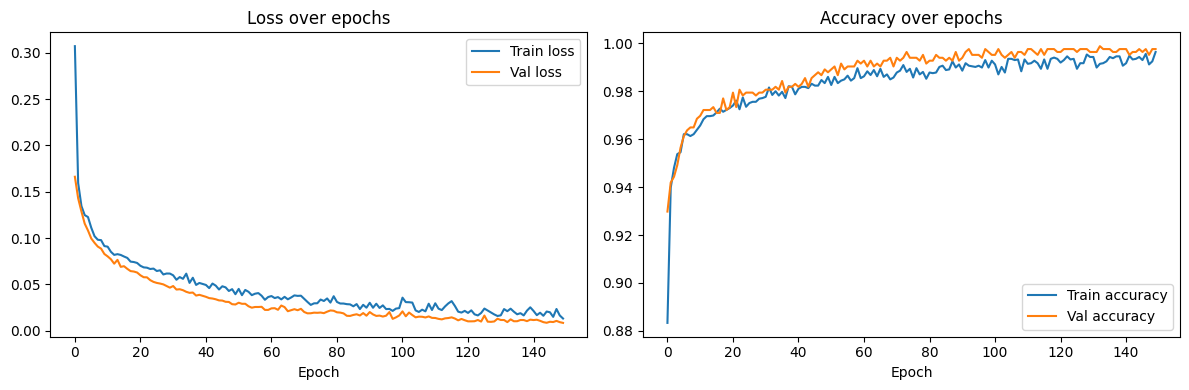

In [13]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score, ConfusionMatrixDisplay)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history["loss"],     label="Train loss")
axes[0].plot(history.history["val_loss"], label="Val loss")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(history.history["accuracy"],     label="Train accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val accuracy")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


In [14]:
# Evaluate on held-out test set
y_pred_prob = model.predict(X_test_sc).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
                             target_names=["Benign", "Malignant"]))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Classification Report ===
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00       521
   Malignant       1.00      1.00      1.00       304

    accuracy                           1.00       825
   macro avg       1.00      1.00      1.00       825
weighted avg       1.00      1.00      1.00       825



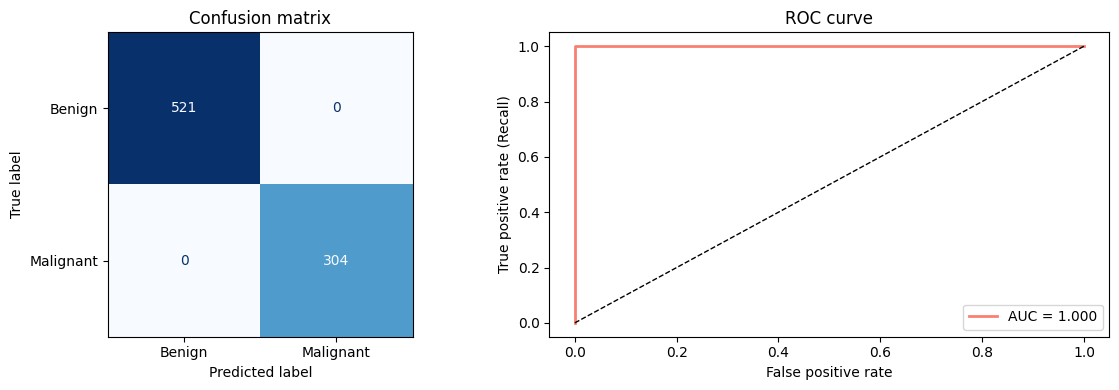

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color="salmon", lw=2, label=f"AUC = {auc_score:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate (Recall)")
axes[1].set_title("ROC curve")
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
# In medical diagnosis, you may want higher recall even at cost of precision.
# Lowering the decision threshold achieves this.
for threshold in [0.5, 0.4, 0.35, 0.3]:
    y_pred_t = (y_pred_prob >= threshold).astype(int)
    report   = classification_report(y_test, y_pred_t,
                                      target_names=["Benign", "Malignant"],
                                      output_dict=True)
    m_recall    = report["Malignant"]["recall"]
    m_precision = report["Malignant"]["precision"]
    m_f1        = report["Malignant"]["f1-score"]
    print(f"Threshold {threshold:.2f} → "
          f"Recall={m_recall:.3f}  Precision={m_precision:.3f}  F1={m_f1:.3f}")


Threshold 0.50 → Recall=1.000  Precision=1.000  F1=1.000
Threshold 0.40 → Recall=1.000  Precision=1.000  F1=1.000
Threshold 0.35 → Recall=1.000  Precision=1.000  F1=1.000
Threshold 0.30 → Recall=1.000  Precision=0.997  F1=0.998


---
## Stage 6 · Save, Interpret & Deploy
Save the trained model and scaler so they can be reloaded later.  
Then inspect which features mattered most.


In [17]:
import joblib

# Save model (Keras native format)
model.save("breast_cancer_model.keras")
print("Model saved → breast_cancer_model.keras")

# Save the scaler — needed to normalise new data at prediction time
joblib.dump(scaler, "scaler.pkl")
print("Scaler saved → scaler.pkl")


Model saved → breast_cancer_model.keras
Scaler saved → scaler.pkl


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


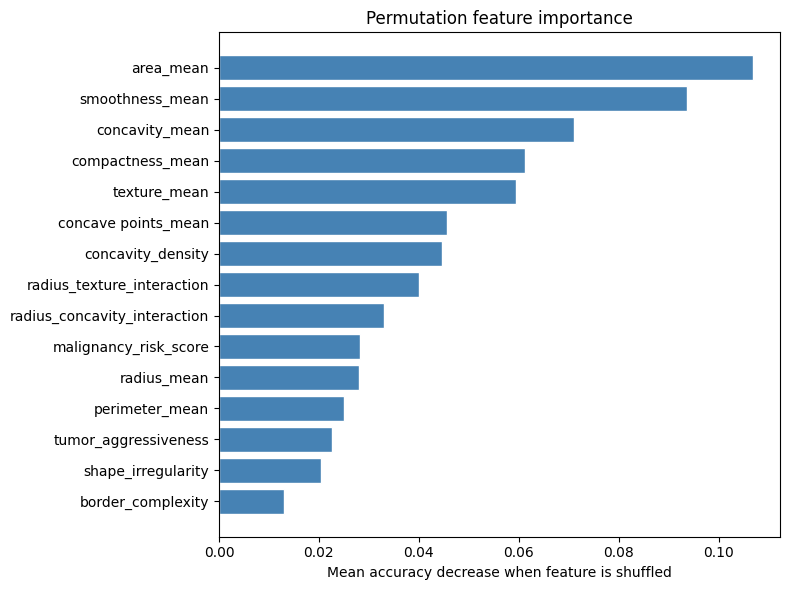

In [18]:
# Permutation importance — shuffle each feature and measure accuracy drop
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrap the Keras model in a sklearn-compatible interface
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model): self.model = model
    def fit(self, X, y): return self
    def predict(self, X): return (self.model.predict(X) >= 0.5).astype(int).flatten()
    def score(self, X, y): return np.mean(self.predict(X) == y)

wrapper = KerasWrapper(model)
result  = permutation_importance(wrapper, X_test_sc, y_test,
                                  n_repeats=10, random_state=SEED, n_jobs=-1)

importance_df = pd.DataFrame({
    "feature":   FEATURE_COLS,
    "importance": result.importances_mean
}).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"],
         color="steelblue", edgecolor="white")
plt.xlabel("Mean accuracy decrease when feature is shuffled")
plt.title("Permutation feature importance")
plt.tight_layout()
plt.show()


In [19]:
# Example: predict on a new, unseen sample (replace values with real data)
new_sample = np.array([[
    14.5,   # radius_mean
    19.2,   # texture_mean
    93.1,   # perimeter_mean
    650.0,  # area_mean
    0.095,  # smoothness_mean
    0.085,  # compactness_mean
    0.065,  # concavity_mean
    0.040,  # concave points_mean
    0.18,   # shape_irregularity
    0.0005, # border_complexity
    0.045,  # tumor_aggressiveness
    278.0,  # radius_texture_interaction
    0.94,   # radius_concavity_interaction
    0.0001, # concavity_density
    25.0    # malignancy_risk_score
]])

new_sample_sc = scaler.transform(new_sample)
prob = model.predict(new_sample_sc)[0][0]
label = "Malignant" if prob >= 0.5 else "Benign"

print(f"Predicted probability of malignancy: {prob:.3f}")
print(f"Predicted class: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted probability of malignancy: 0.496
Predicted class: Benign


---
## Next steps & ideas
| Idea | How |
|---|---|
| Try deeper networks | Add more `Dense` layers in `build_model()` |
| Hyperparameter tuning | Use `keras_tuner` to search learning rate & dropout |
| Explainability (SHAP) | `pip install shap` then `shap.DeepExplainer` |
| Cross-validation | `sklearn.model_selection.StratifiedKFold` |
| Compare with baselines | `sklearn` `RandomForestClassifier`, `LogisticRegression` |
| Build a demo UI | `pip install gradio` — spin up a prediction web app in ~10 lines |
